In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.drop(columns=['User ID', 'Gender'], inplace=True)

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
18,46,28000,1
152,31,76000,0
273,39,106000,1
331,48,119000,1
214,47,43000,0


In [6]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((280, 2), (120, 2))

# Standardization

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
X_train_scaled = scaler.fit_transform(X_train)

In [10]:
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [11]:
print('- Mean of Age              :', round(scaler.mean_[0],4))
print('- Mean of EstimatedSalary  :', round(scaler.mean_[1],4))

- Mean of Age              : 37.575
- Mean of EstimatedSalary  : 70589.2857


In [12]:
X_test_scaled = scaler.transform(X_test)

In [13]:
# Numpy array
X_train_scaled

array([[-0.84252154,  0.1301563 ],
       [ 0.04175763,  0.2777019 ],
       [ 0.72953032, -1.31579061],
       [ 1.61380949,  1.10395728],
       [ 0.82778356, -1.40431797],
       [-1.43204099, -1.25677236],
       [-0.05649561,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 ,  0.01211982],
       [ 1.31904976,  2.22530386],
       [ 0.14001087,  0.74984783],
       [-1.33378775,  0.54328399],
       [ 2.00682245,  0.72033871],
       [-1.23553451, -1.43382709],
       [ 0.33651735, -0.34198963],
       [-0.94077478,  0.54328399],
       [ 0.43477059,  0.2777019 ],
       [ 0.43477059,  1.10395728],
       [ 0.82778356,  0.74984783],
       [ 0.9260368 ,  1.25150288],
       [-0.44950858, -1.25677236],
       [-1.82505395, -1.34529973],
       [ 1.12254328,  0.54328399],
       [-0.64601506, -1.64039093],
       [-0.7442683 ,  0.24819278],
       [ 1.02429004,  2.07775825],
       [-0.54776182,  1.36953936],
       [-0.05649561,  0.01211982],
       [-1.9233072 ,

In [14]:
# Numpy array
X_test_scaled

array([[ 0.82778356, -1.43382709],
       [ 2.10507569,  0.51377487],
       [-0.94077478, -0.78462644],
       [ 1.02429004,  0.74984783],
       [-0.84252154, -1.25677236],
       [-0.7442683 , -0.25346227],
       [ 0.9260368 ,  1.07444816],
       [-0.84252154,  0.36622926],
       [ 0.23826411,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 , -0.16493491],
       [ 1.51555624, -1.07971764],
       [-1.43204099, -0.66658995],
       [-1.72680071, -1.40431797],
       [-0.7442683 ,  0.48426575],
       [-0.2530021 ,  1.10395728],
       [ 1.417303  , -0.96168116],
       [ 0.82778356,  0.10064718],
       [ 0.14001087, -0.84364468],
       [ 1.81031597, -0.31248051],
       [-1.53029423, -1.28628149],
       [-0.84252154,  0.2777019 ],
       [ 0.9260368 , -1.40431797],
       [ 2.10507569,  0.15966542],
       [-1.82505395, -1.52235445],
       [ 1.31904976, -1.40431797],
       [ 0.43477059,  0.2777019 ],
       [-0.05649561, -0.51904435],
       [ 1.71206273,

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [16]:
X_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [17]:
X_train_scaled

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318
...,...,...
275,-1.333788,-1.286281
276,-1.137281,-1.050209
277,0.533024,1.841685
278,0.140011,0.189175


In [18]:
X_test

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000
...,...,...
60,27,20000
79,26,17000
285,37,93000
305,42,54000


In [19]:
X_test_scaled

,Age,EstimatedSalary
0,0.827784,-1.433827
1,2.105076,0.513775
2,-0.940775,-0.784626
3,1.024290,0.749848
4,-0.842522,-1.256772
...,...,...
115,-1.039028,-1.492845
116,-1.137281,-1.581373
117,-0.056496,0.661320
118,0.434771,-0.489535


In [20]:
# Original Data
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [21]:
# Scaled data
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


# Outliers : No effect of Standardization

In [22]:
outlier_data = pd.DataFrame({
    'Age':[5,90,95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

In [23]:
df = pd.concat([df, outlier_data], ignore_index=True)

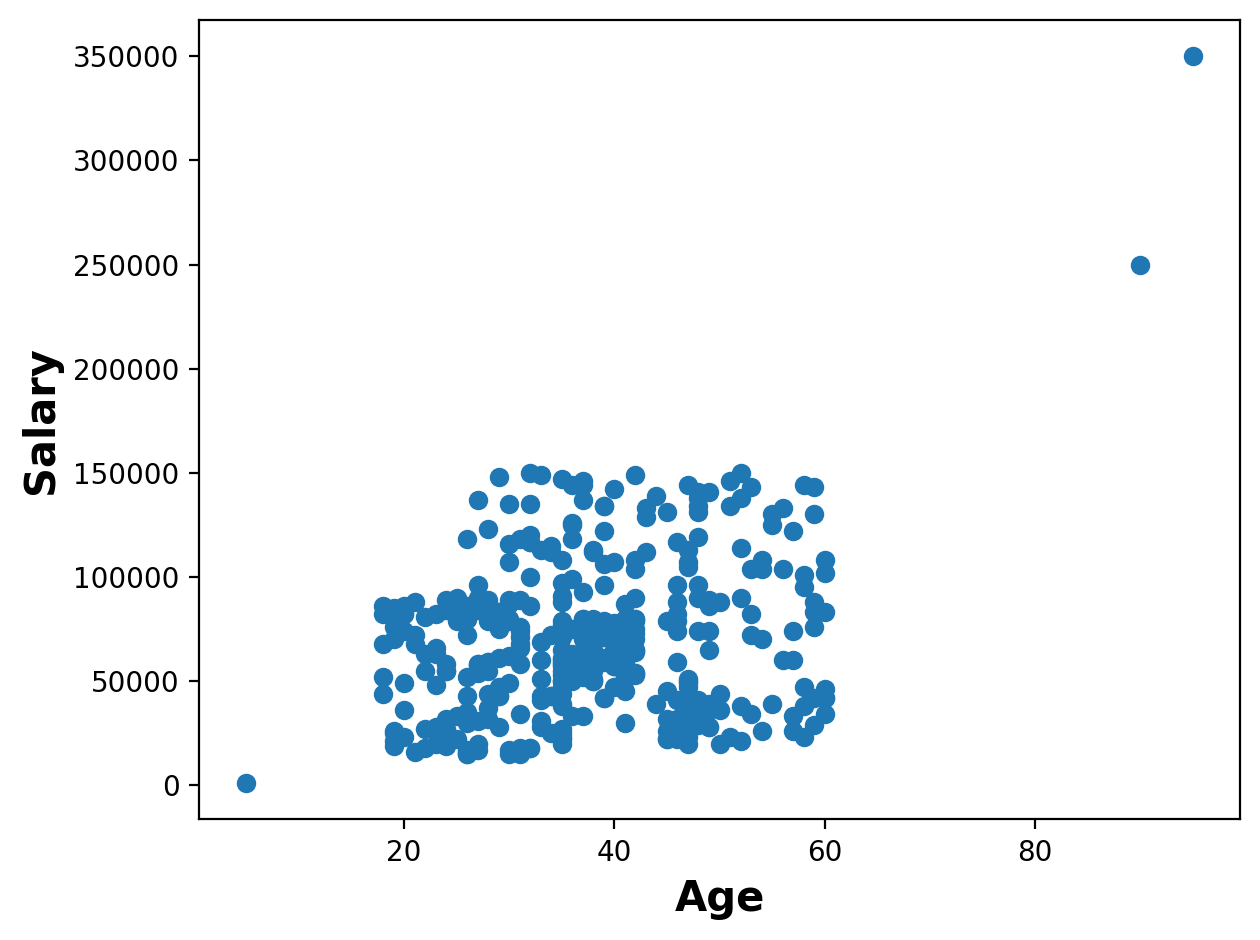

In [24]:
plt.figure(dpi=200)
plt.xlabel('Age', fontsize=15, fontweight='bold')
plt.ylabel('Salary', fontsize=15, fontweight='bold')
plt.scatter(df['Age'], df['EstimatedSalary'])
plt.tight_layout()
plt.show()

# Model with Outliers

In [25]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

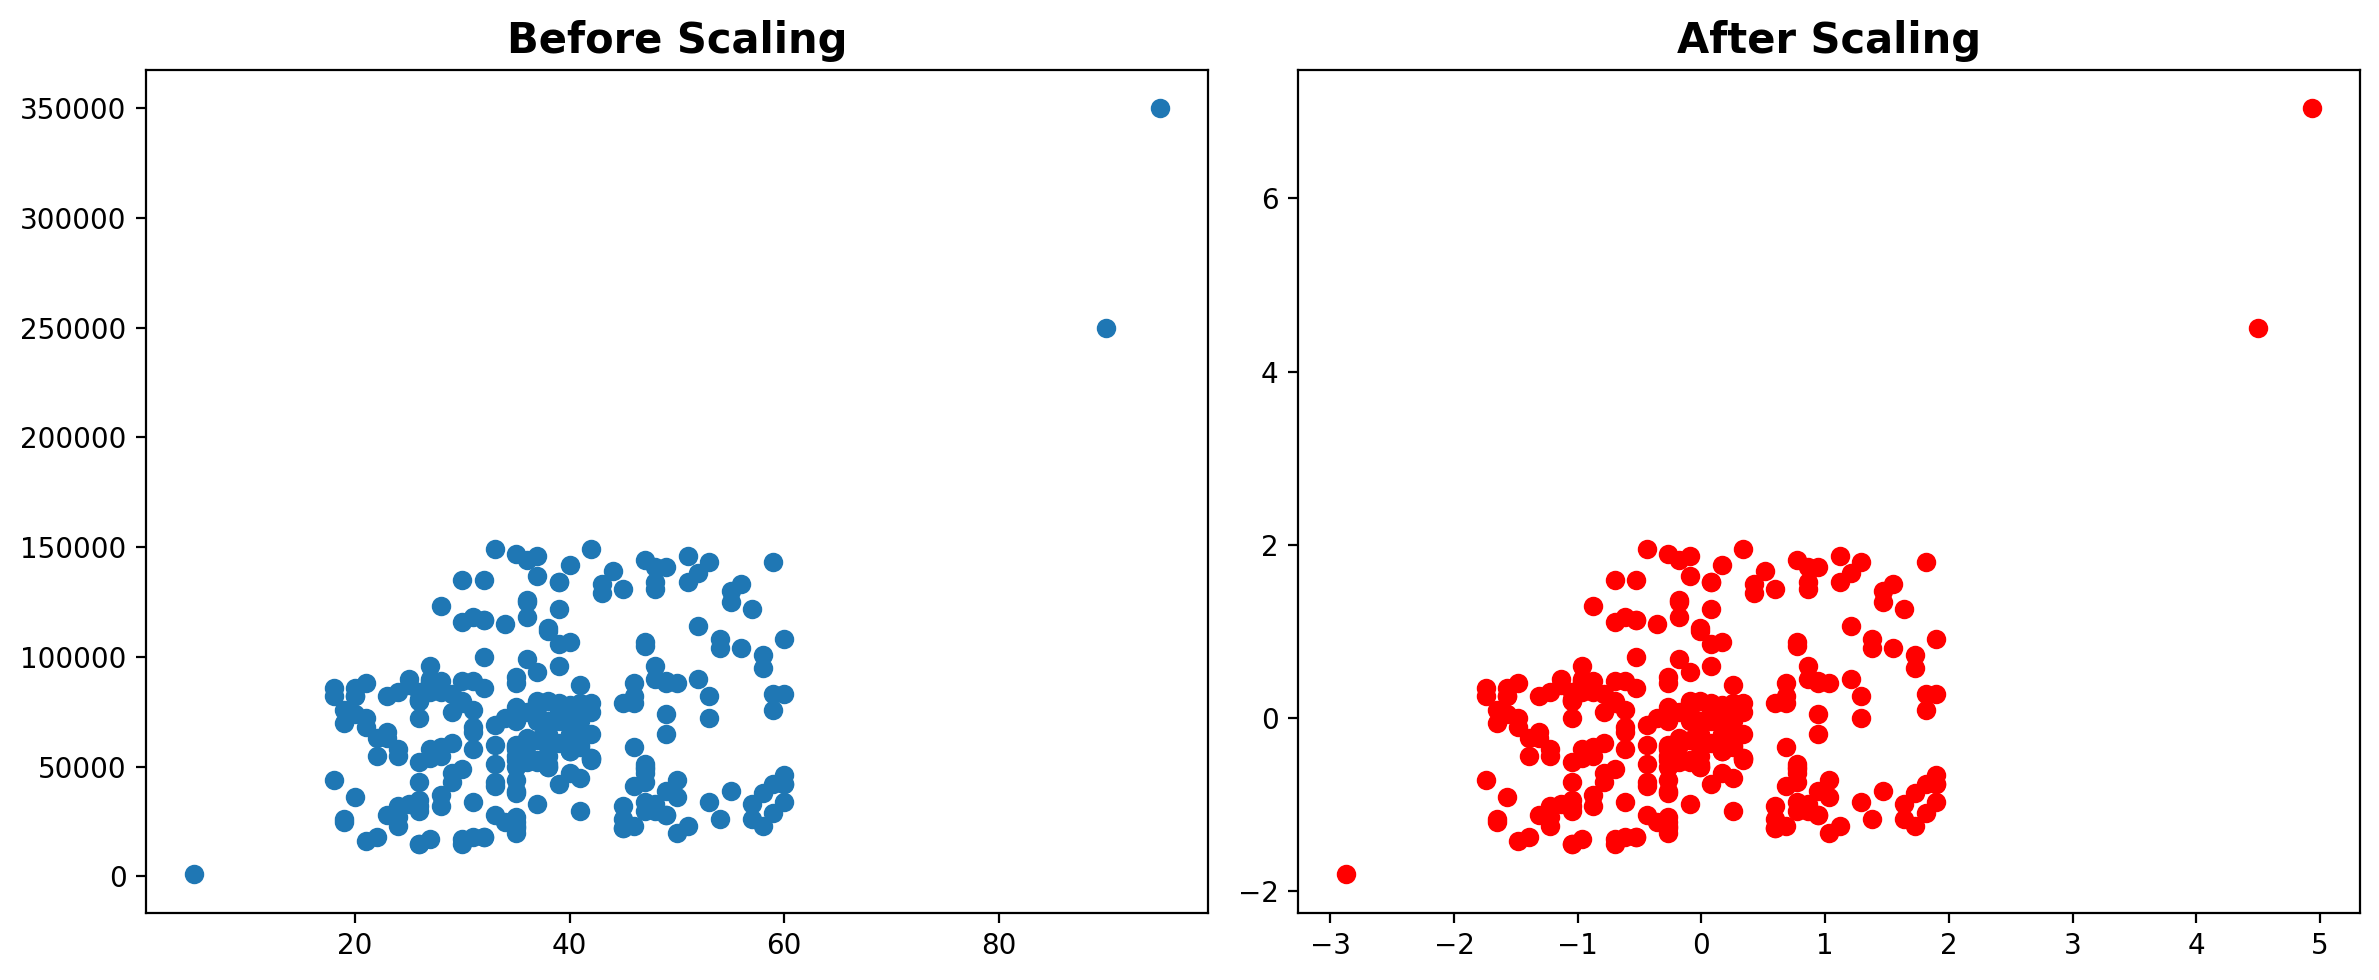

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), dpi=200)
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling", fontsize=15, fontweight='bold')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()